# Articulability Gap: Dense vs. AutoMetrics

Comparing **dense fine-tuning** (inarticulate: learns from data without explaining why) vs.
**AutoMetrics** (articulated: generates explicit evaluation criteria and scores along them).

- **Dense models**: LLaMA reward models fine-tuned on press release newsworthiness labels
- **AutoMetrics**: Iterative metric discovery + L1 logistic regression on LLM-scored rubrics

Key question: How much performance do we sacrifice for interpretability?

## 0. Sync Data from Server

In [22]:
# Pull only summary files from dense runs (not model weights/checkpoints)
REMOTE = "sk3:/lfs/skampere3/0/alexspan/norm-research"

# Dense 8B: just test metrics JSON and optuna DB per subset
for subset in ["subset_0p1", "subset_0p2", "subset_0p3"]:
    !rsync -avz \
        --include="optuna_best_trial_test_metrics.json" \
        --include="optuna_study.db" \
        --exclude="*" \
        {REMOTE}/runs/press_release_sweep_llama-8b/{subset}/ \
        ../runs/press_release_sweep_llama-8b/{subset}/

# Dense 70B: same
!mkdir -p ../runs/press_release_sweep_llama-70b/subset_0p1
!rsync -avz \
    --include="optuna_best_trial_test_metrics.json" \
    --include="optuna_study.db" \
    --exclude="*" \
    {REMOTE}/runs/press_release_sweep_llama-70b/subset_0p1/ \
    ../runs/press_release_sweep_llama-70b/subset_0p1/ 2>/dev/null || echo "70b not yet available"

# Bradley-Terry 8B
!mkdir -p ../runs/press_release_sweep_bradley_terry_llama-8b/subset_0p1
!rsync -avz \
    --include="optuna_best_trial_test_metrics.json" \
    --include="optuna_study.db" \
    --exclude="*" \
    {REMOTE}/runs/press_release_sweep_bradley_terry_llama-8b/subset_0p1/ \
    ../runs/press_release_sweep_bradley_terry_llama-8b/subset_0p1/

# AutoMetrics: just the JSONL/CSV summary files (not label_cache)
!rsync -avz \
    --include="*.jsonl" --include="*.json" --include="*.csv" \
    --exclude="label_cache/" --exclude="*/" \
    {REMOTE}/outputs/iterative_autometrics/press_release_vllm_70b/ \
    ../outputs/iterative_autometrics/press_release_vllm_70b/

receiving incremental file list
./
optuna_best_trial_test_metrics.json
optuna_study.db

sent 1,268 bytes  received 3,666 bytes  3,289.33 bytes/sec
total size is 131,413  speedup is 26.63
receiving incremental file list
./
optuna_study.db

sent 1,243 bytes  received 3,133 bytes  2,917.33 bytes/sec
total size is 131,415  speedup is 30.03
receiving incremental file list

sent 89 bytes  received 85 bytes  116.00 bytes/sec
total size is 122,880  speedup is 706.21
receiving incremental file list
./
optuna_study.db

sent 1,207 bytes  received 1,030 bytes  344.15 bytes/sec
total size is 126,976  speedup is 56.76
receiving incremental file list

sent 89 bytes  received 85 bytes  348.00 bytes/sec
total size is 151,552  speedup is 870.99
receiving incremental file list
config.json
eval_metrics.jsonl
iterations.jsonl
pairs.jsonl
test_metrics.jsonl

sent 1,537 bytes  received 6,358 bytes  15,790.00 bytes/sec
total size is 202,097  speedup is 25.60


In [23]:
import json
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

RUNS_DIR = Path("../runs")
AUTOMETRICS_DIR = Path("../outputs/iterative_autometrics/press_release_vllm_70b")

## 0b. Dataset: Example Press Releases

The task is predicting **newsworthiness**: whether a press release gets picked up by a news outlet.
- **Positive**: press release was covered by at least one news article
- **Negative**: press release was not picked up

Below are representative examples from each class.

In [24]:
import re
import textwrap

SPLIT_DIR = Path("../datasets/press-releases/press_release_modeling_dataset.csv")
sample_df = pd.read_csv(SPLIT_DIR / "train.csv.gz", low_memory=False)
sample_df["text_len"] = sample_df["text"].str.len()

# Filter for medium-length, clean-looking texts
clean = sample_df[
    (sample_df["text_len"] > 2000) & (sample_df["text_len"] < 6000)
    & ~sample_df["text"].str.contains("<div|<script|{\"data", regex=True, na=False)
]

print(f"Dataset: {len(sample_df)} total rows, {len(clean)} clean medium-length")
print(f"Label distribution: {dict(sample_df['judgement'].value_counts())}")
print()

for label, subset in [
    ("POSITIVE (newsworthy — picked up by news outlet)",
     clean[clean["judgement"] == True].sample(2, random_state=99)),
    ("NEGATIVE (not newsworthy — not picked up)",
     clean[clean["judgement"] == False].sample(2, random_state=99)),
]:
    print(f"{'='*90}")
    print(f"  {label}")
    print(f"{'='*90}")
    for _, row in subset.iterrows():
        print(f"\n--- Company: {row['press_release_company']} | Date: {row['press_release_date']} ---")
        if pd.notna(row.get("news_article_domain")):
            print(f"    Picked up by: {row['news_article_domain']}")
        text = re.sub(r"\s+", " ", row["text"][:1200]).strip()
        print(textwrap.fill(text, width=100, initial_indent="    ", subsequent_indent="    "))
        print(f"    [...{len(row['text'])} chars total]")
        print()

del sample_df, clean  # free memory

Dataset: 102504 total rows, 39263 clean medium-length
Label distribution: {False: 59673, True: 42831}

  POSITIVE (newsworthy — picked up by news outlet)

--- Company: progressive_mediaroom | Date: 2017-12-21T00:00:00Z ---
    Picked up by: ['progressive', 'progressive']
    Skip to Main Content Menu Explore Products Claims About Us Answers 1-855-347-3939, call us Log
    In Subscribe Subscribe to media alerts Progressive's 'Thread' Shines a Light on Progress Brand
    extension celebrates 'people like us' MAYFIELD VILLAGE, Ohio — September 23, 2013 — For many
    people, the name Progressive conjures thoughts of the company's perky sales clerk, Flo. In its
    new brand extension, called The Thread, Progressive introduces consumers to the real company
    behind its popular, apron-clad icon. The first Thread ad, Everything, launches this week during
    primetime network premiers, including The Voice and The Big Bang Theory. It poses the question
    "what does an apron have to do wit

## 1. Load Dense Model Results

Dense models are LLaMA reward models (classification head on top of the base LLM)
fine-tuned via Optuna hyperparameter sweep. Each subset (0p1, 0p2, 0p3) uses
10%, 20%, 30% of the training data respectively.

In [25]:
def load_dense_test_metrics(run_dir):
    """Load optuna best trial test metrics from a sweep directory."""
    path = run_dir / "optuna_best_trial_test_metrics.json"
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

def load_optuna_best_eval(run_dir):
    """Load best eval AUC from Optuna study DB."""
    db_path = run_dir / "optuna_study.db"
    if not db_path.exists():
        return None
    try:
        conn = sqlite3.connect(str(db_path))
        cur = conn.cursor()
        cur.execute("SELECT MAX(value) FROM trial_values")
        result = cur.fetchone()
        conn.close()
        return result[0] if result else None
    except Exception as e:
        print(f"  Error reading {db_path}: {e}")
        return None

def load_best_trial_training_history(run_dir, trial_num):
    """Load training history for a specific trial."""
    path = run_dir / f"trial_{trial_num:04d}" / "training_history.json"
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None

# Collect all dense results
dense_results = []

# LLaMA-8B binary classification
for subset, data_frac in [("subset_0p1", 0.1), ("subset_0p2", 0.2), ("subset_0p3", 0.3)]:
    run_dir = RUNS_DIR / "press_release_sweep_llama-8b" / subset
    if not run_dir.exists():
        continue
    test = load_dense_test_metrics(run_dir)
    best_eval = load_optuna_best_eval(run_dir)
    entry = {
        "model": "LLaMA-8B",
        "method": "Dense (Binary)",
        "data_fraction": data_frac,
        "subset": subset,
        "best_eval_auc": best_eval,
    }
    if test:
        entry.update({f"test_{k}": v for k, v in test["metrics"].items()})
        entry["best_trial"] = test["best_trial_number"]
    dense_results.append(entry)

# LLaMA-70B binary classification (may be in progress)
for subset, data_frac in [("subset_0p1", 0.1)]:
    run_dir = RUNS_DIR / "press_release_sweep_llama-70b" / subset
    if not run_dir.exists():
        print(f"70b {subset} not found (may need rsync)")
        continue
    test = load_dense_test_metrics(run_dir)
    best_eval = load_optuna_best_eval(run_dir)
    entry = {
        "model": "LLaMA-70B",
        "method": "Dense (Binary)",
        "data_fraction": data_frac,
        "subset": subset,
        "best_eval_auc": best_eval,
    }
    if test:
        entry.update({f"test_{k}": v for k, v in test["metrics"].items()})
        entry["best_trial"] = test["best_trial_number"]
    dense_results.append(entry)

# Bradley-Terry 8B
for subset, data_frac in [("subset_0p1", 0.1)]:
    run_dir = RUNS_DIR / "press_release_sweep_bradley_terry_llama-8b" / subset
    if not run_dir.exists():
        continue
    test = load_dense_test_metrics(run_dir)
    best_eval = load_optuna_best_eval(run_dir)
    entry = {
        "model": "LLaMA-8B",
        "method": "Dense (Bradley-Terry)",
        "data_fraction": data_frac,
        "subset": subset,
        "best_eval_auc": best_eval,
    }
    if test:
        entry.update({f"test_{k}": v for k, v in test["metrics"].items()})
        entry["best_trial"] = test["best_trial_number"]
    dense_results.append(entry)

dense_df = pd.DataFrame(dense_results)
print(f"Dense model configurations: {len(dense_df)}")
dense_df

Dense model configurations: 5


,model,method,data_fraction,subset,best_eval_auc,test_loss,test_accuracy,test_precision,test_recall,test_f1,test_auc,best_trial
0,LLaMA-8B,Dense (Binary),0.1,subset_0p1,0.667274,0.660267,0.612689,0.529395,0.694868,0.600949,0.664681,8.0
1,LLaMA-8B,Dense (Binary),0.2,subset_0p2,0.690184,0.633144,0.641798,0.595446,0.457047,0.517147,0.683299,3.0
2,LLaMA-8B,Dense (Binary),0.3,subset_0p3,0.693271,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LLaMA-70B,Dense (Binary),0.1,subset_0p1,0.638894,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LLaMA-8B,Dense (Bradley-Terry),0.1,subset_0p1,0.638860,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Load AutoMetrics Results

AutoMetrics uses LLaMA-3.3-70B-Instruct to iteratively discover evaluation metrics,
score documents along those metrics, and fit an L1 logistic regression.

In [26]:
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def dedup_last_run(records, key="iteration"):
    seen = {}
    for rec in records:
        seen[rec[key]] = rec
    return list(seen.values())

am_iterations = dedup_last_run(load_jsonl(AUTOMETRICS_DIR / "iterations.jsonl"))
am_test = pd.DataFrame(dedup_last_run(load_jsonl(AUTOMETRICS_DIR / "test_metrics.jsonl")))

print(f"AutoMetrics: {len(am_iterations)} iterations (0..{am_iterations[-1]['iteration']})")

# Get final iteration metrics
final_am = am_iterations[-1]
final_test = final_am.get("test", {})
best_test_iter = am_test.loc[am_test["roc_auc"].idxmax()] if len(am_test) > 0 else {}

print(f"Final iteration: {final_am['iteration']}")
print(f"  Active metrics: {final_am['num_active_metrics']}")
print(f"  Active interactions: {len(final_am.get('active_interactions', {}))}")
print(f"  Test ROC-AUC: {final_test.get('roc_auc', 'N/A')}")
print(f"  Best test ROC-AUC (any iter): {best_test_iter.get('roc_auc', 'N/A')} at iter {best_test_iter.get('iteration', '?')}")

AutoMetrics: 9 iterations (0..8)
Final iteration: 8
  Active metrics: 12
  Active interactions: 13
  Test ROC-AUC: 0.5234598123215014
  Best test ROC-AUC (any iter): 0.5852713178294574 at iter 3.0


## 3. Comparison: ROC-AUC

Primary comparison metric: ROC-AUC on the held-out test set.

In [27]:
# Build comparison dataframe
comparison_rows = []

# Dense results
for _, row in dense_df.iterrows():
    test_auc = row.get("test_auc", row.get("best_eval_auc"))
    has_test = pd.notna(row.get("test_auc"))
    label = f"{row['model']}\n{row['method']}\n({int(row['data_fraction']*100)}% data)"
    comparison_rows.append({
        "label": label,
        "model": row["model"],
        "approach": "Dense",
        "method": row["method"],
        "data_fraction": row["data_fraction"],
        "test_auc": test_auc,
        "metric_type": "test" if has_test else "eval (best)",
    })

# AutoMetrics: best iteration
if len(am_test) > 0:
    best_am_auc = am_test["roc_auc"].max()
    best_am_iter = int(am_test.loc[am_test["roc_auc"].idxmax(), "iteration"])
else:
    best_am_auc = final_test.get("roc_auc", 0)
    best_am_iter = final_am["iteration"]

comparison_rows.append({
    "label": f"LLaMA-70B\nAutoMetrics\n(best iter {best_am_iter})",
    "model": "LLaMA-70B",
    "approach": "AutoMetrics",
    "method": "AutoMetrics (L1 + rubrics)",
    "data_fraction": None,
    "test_auc": best_am_auc,
    "metric_type": "test",
})

# AutoMetrics: final iteration
final_am_test_auc = final_test.get("roc_auc", 0)
comparison_rows.append({
    "label": f"LLaMA-70B\nAutoMetrics\n(final iter {final_am['iteration']})",
    "model": "LLaMA-70B",
    "approach": "AutoMetrics",
    "method": "AutoMetrics (L1 + rubrics)",
    "data_fraction": None,
    "test_auc": final_am_test_auc,
    "metric_type": "test",
})

comp_df = pd.DataFrame(comparison_rows)
comp_df

,label,model,approach,method,data_fraction,test_auc,metric_type
0,LLaMA-8B\nDense (Binary)\n(10% data),LLaMA-8B,Dense,Dense (Binary),0.1,0.664681,test
1,LLaMA-8B\nDense (Binary)\n(20% data),LLaMA-8B,Dense,Dense (Binary),0.2,0.683299,test
2,LLaMA-8B\nDense (Binary)\n(30% data),LLaMA-8B,Dense,Dense (Binary),0.3,NaN,eval (best)
3,LLaMA-70B\nDense (Binary)\n(10% data),LLaMA-70B,Dense,Dense (Binary),0.1,NaN,eval (best)
4,LLaMA-8B\nDense (Bradley-Terry)\n(10% data),LLaMA-8B,Dense,Dense (Bradley-Terry),0.1,NaN,eval (best)
5,LLaMA-70B\nAutoMetrics\n(best iter 3),LLaMA-70B,AutoMetrics,AutoMetrics (L1 + rubrics),NaN,0.585271,test
6,LLaMA-70B\nAutoMetrics\n(final iter 8),LLaMA-70B,AutoMetrics,AutoMetrics (L1 + rubrics),NaN,0.523460,test


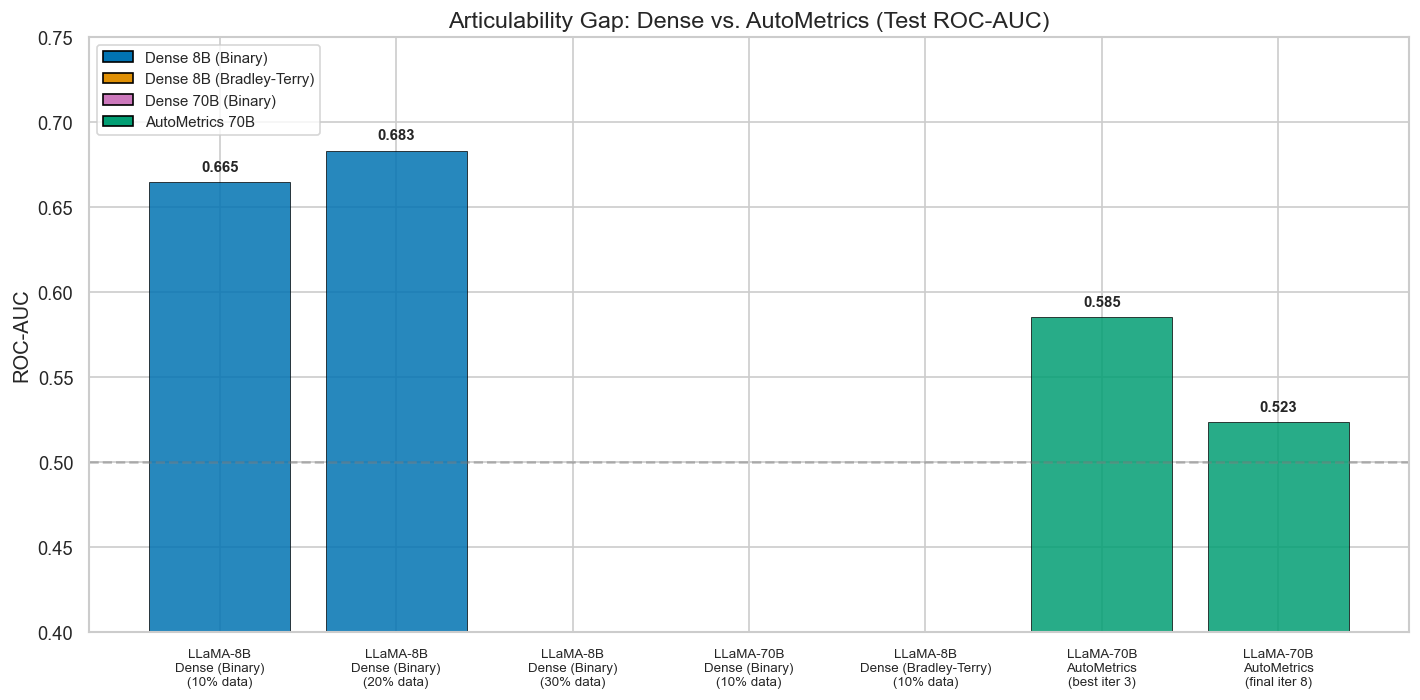

In [28]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

colors = []
for _, row in comp_df.iterrows():
    if row["approach"] == "AutoMetrics":
        colors.append("C2")
    elif "Bradley-Terry" in row["method"]:
        colors.append("C1")
    elif row["model"] == "LLaMA-70B":
        colors.append("C4")
    else:
        colors.append("C0")

bars = ax.bar(range(len(comp_df)), comp_df["test_auc"], color=colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(comp_df)))
ax.set_xticklabels(comp_df["label"], fontsize=8, ha="center")
ax.set_ylabel("ROC-AUC")
ax.set_title("Articulability Gap: Dense vs. AutoMetrics (Test ROC-AUC)", fontsize=14)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")

# Annotate bars
for bar, (_, row) in zip(bars, comp_df.iterrows()):
    val = row["test_auc"]
    if pd.notna(val):
        suffix = "" if row["metric_type"] == "test" else " (eval)"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}{suffix}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="C0", edgecolor="black", label="Dense 8B (Binary)"),
    Patch(facecolor="C1", edgecolor="black", label="Dense 8B (Bradley-Terry)"),
    Patch(facecolor="C4", edgecolor="black", label="Dense 70B (Binary)"),
    Patch(facecolor="C2", edgecolor="black", label="AutoMetrics 70B"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)

ax.set_ylim(0.4, max(comp_df["test_auc"].max() + 0.05, 0.75))
fig.tight_layout()
plt.show()

## 4. AutoMetrics Performance Over Iterations

How does AutoMetrics performance evolve as more metrics are discovered?

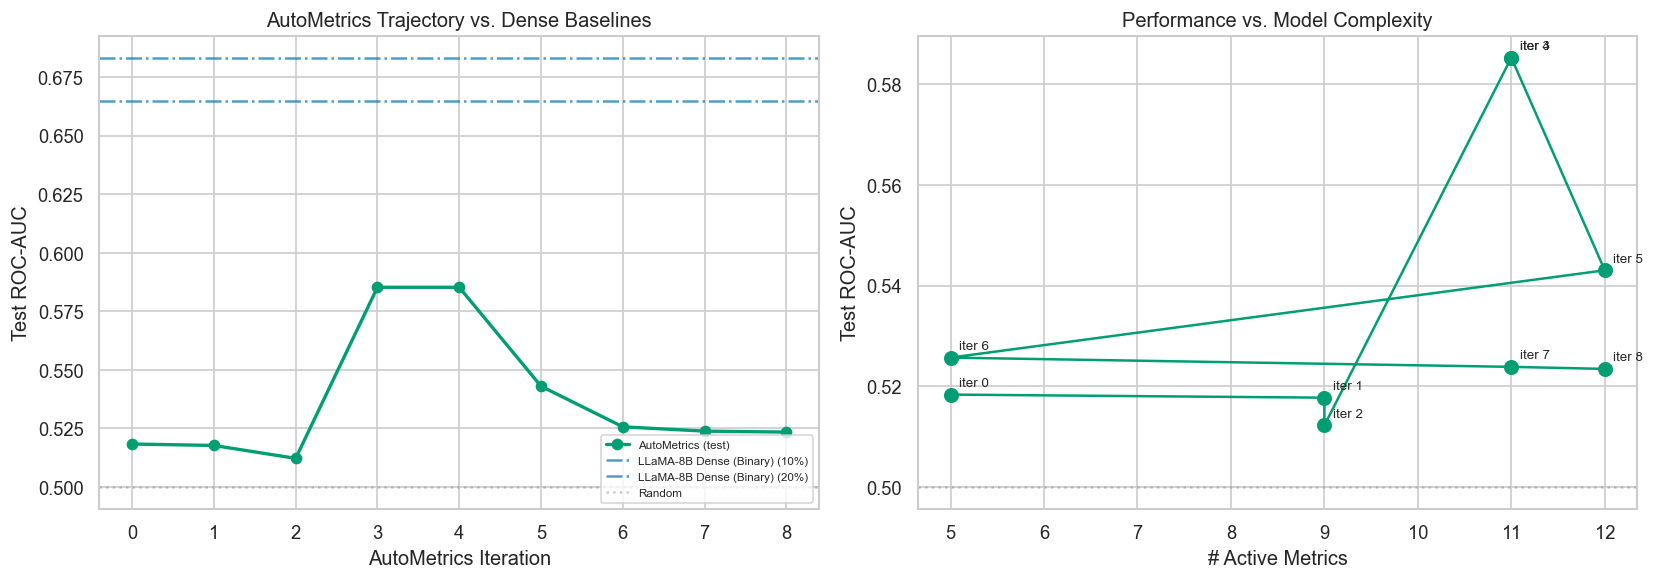

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: test ROC-AUC over iterations with dense baselines
ax = axes[0]
if len(am_test) > 0:
    ax.plot(am_test["iteration"], am_test["roc_auc"], "o-", color="C2", label="AutoMetrics (test)", linewidth=2)

# Add dense baselines as horizontal lines
for _, row in dense_df.iterrows():
    test_auc = row.get("test_auc", row.get("best_eval_auc"))
    if pd.notna(test_auc):
        style = "--" if "Bradley" in row["method"] else "-."
        color = "C1" if "Bradley" in row["method"] else ("C4" if row["model"] == "LLaMA-70B" else "C0")
        label = f"{row['model']} {row['method']} ({int(row['data_fraction']*100)}%)"
        ax.axhline(test_auc, linestyle=style, color=color, alpha=0.7, label=label)

ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4, label="Random")
ax.set_xlabel("AutoMetrics Iteration")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("AutoMetrics Trajectory vs. Dense Baselines")
ax.legend(fontsize=7, loc="lower right")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Right: number of active metrics vs performance
ax = axes[1]
n_metrics = [it["num_active_metrics"] for it in am_iterations]
test_aucs = [am_test[am_test["iteration"] == it["iteration"]]["roc_auc"].values[0]
             if it["iteration"] in am_test["iteration"].values else None
             for it in am_iterations]

valid = [(n, a) for n, a in zip(n_metrics, test_aucs) if a is not None]
if valid:
    ns, aucs = zip(*valid)
    ax.plot(ns, aucs, "o-", color="C2", markersize=8)
    for n, a, it in zip(ns, aucs, [it["iteration"] for it in am_iterations if it["iteration"] in am_test["iteration"].values]):
        ax.annotate(f"iter {it}", (n, a), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_xlabel("# Active Metrics")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Performance vs. Model Complexity")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)

fig.tight_layout()
plt.show()

## 4b. AutoMetrics: Interaction Terms & Model Complexity

Track how L1 selects interaction terms and prunes the model over iterations.

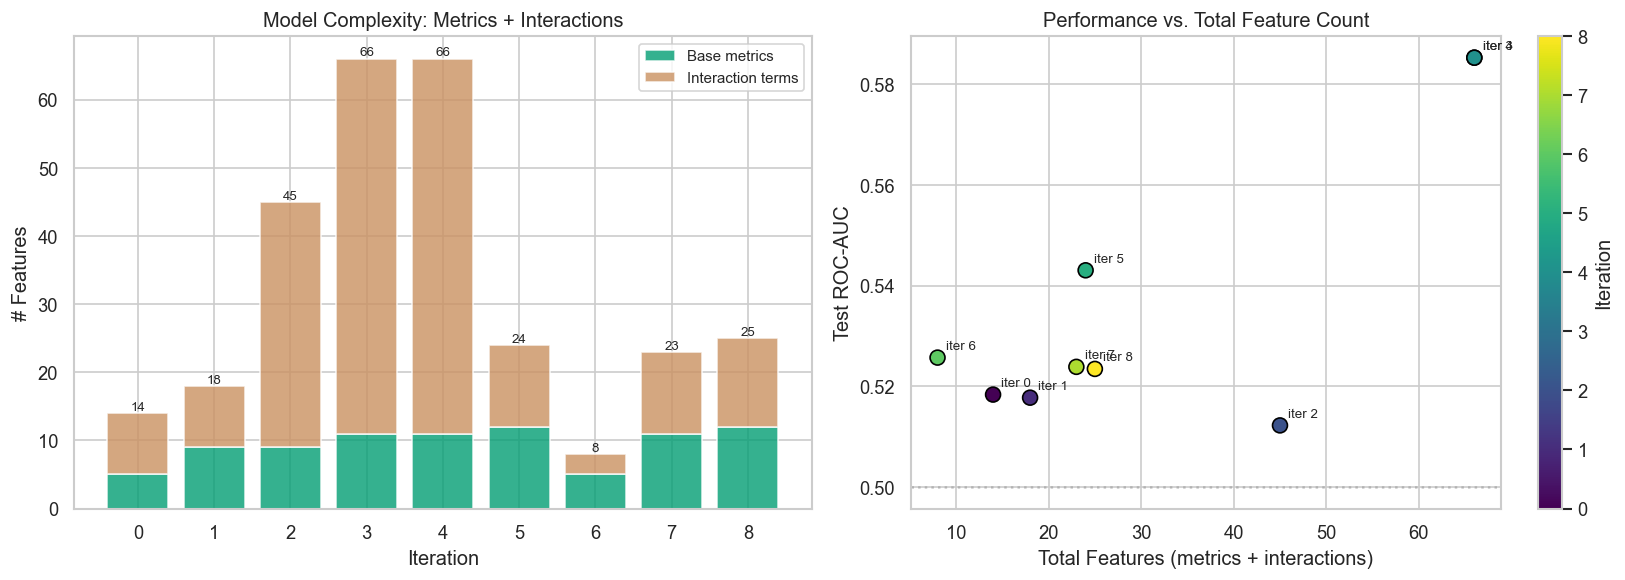


Complexity summary:
 iteration  num_metrics  num_interactions  total_features  test_roc_auc
         0            5                 9              14      0.518360
         1            9                 9              18      0.517748
         2            9                36              45      0.512240
         3           11                55              66      0.585271
         4           11                55              66      0.585271
         5           12                12              24      0.543044
         6            5                 3               8      0.525704
         7           11                12              23      0.523868
         8           12                13              25      0.523460


In [30]:
# Extract interaction and metric counts per iteration
am_complexity = []
for it in am_iterations:
    am_complexity.append({
        "iteration": it["iteration"],
        "num_metrics": it["num_active_metrics"],
        "num_interactions": len(it.get("active_interactions", {})),
        "total_features": it["num_active_metrics"] + len(it.get("active_interactions", {})),
        "test_roc_auc": it.get("test", {}).get("roc_auc"),
    })
am_cx = pd.DataFrame(am_complexity)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar of metrics + interactions
ax = axes[0]
ax.bar(am_cx["iteration"], am_cx["num_metrics"], label="Base metrics", color="C2", alpha=0.8)
ax.bar(am_cx["iteration"], am_cx["num_interactions"], bottom=am_cx["num_metrics"],
       label="Interaction terms", color="C5", alpha=0.8)
ax.set_xlabel("Iteration")
ax.set_ylabel("# Features")
ax.set_title("Model Complexity: Metrics + Interactions")
ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for _, row in am_cx.iterrows():
    ax.annotate(f"{int(row['total_features'])}",
                (row["iteration"], row["total_features"]),
                ha="center", va="bottom", fontsize=8)

# Right: total features vs test AUC
ax = axes[1]
valid = am_cx.dropna(subset=["test_roc_auc"])
if len(valid) > 0:
    sc = ax.scatter(valid["total_features"], valid["test_roc_auc"],
                    c=valid["iteration"], cmap="viridis", s=80, edgecolors="black", zorder=3)
    for _, row in valid.iterrows():
        ax.annotate(f"iter {int(row['iteration'])}",
                    (row["total_features"], row["test_roc_auc"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
    plt.colorbar(sc, ax=ax, label="Iteration")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
ax.set_xlabel("Total Features (metrics + interactions)")
ax.set_ylabel("Test ROC-AUC")
ax.set_title("Performance vs. Total Feature Count")

fig.tight_layout()
plt.show()

print("\nComplexity summary:")
print(am_cx.to_string(index=False))

## 5. Dense Model: Data Scaling

How does dense model performance scale with training data size?

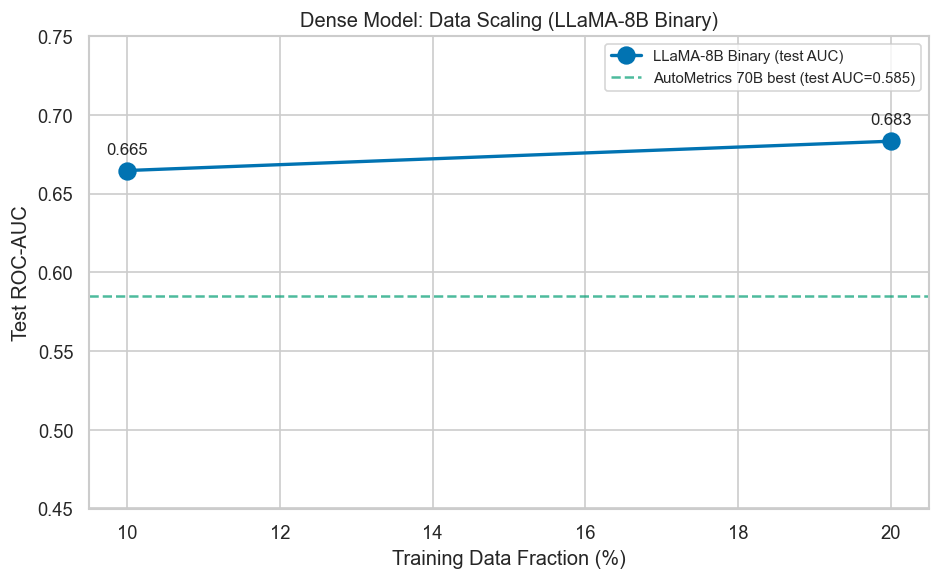

In [31]:
# Filter to only rows with test AUC
binary_8b = dense_df[(dense_df["model"] == "LLaMA-8B") & (dense_df["method"] == "Dense (Binary)")].copy()

if "test_auc" in binary_8b.columns and binary_8b["test_auc"].notna().any():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(binary_8b["data_fraction"] * 100, binary_8b["test_auc"], "o-", color="C0",
            markersize=10, linewidth=2, label="LLaMA-8B Binary (test AUC)")

    for _, row in binary_8b.iterrows():
        if pd.notna(row.get("test_auc")):
            ax.annotate(f"{row['test_auc']:.3f}",
                        (row['data_fraction'] * 100, row['test_auc']),
                        textcoords="offset points", xytext=(0, 10), ha="center", fontsize=10)

    # Add AutoMetrics reference
    if len(am_test) > 0:
        best_am = am_test["roc_auc"].max()
        ax.axhline(best_am, color="C2", linestyle="--", alpha=0.7,
                   label=f"AutoMetrics 70B best (test AUC={best_am:.3f})")

    ax.set_xlabel("Training Data Fraction (%)")
    ax.set_ylabel("Test ROC-AUC")
    ax.set_title("Dense Model: Data Scaling (LLaMA-8B Binary)")
    ax.legend(fontsize=9)
    ax.set_ylim(0.45, 0.75)
    fig.tight_layout()
    plt.show()
else:
    print("No test AUC data available for 8B binary models. Check if sweeps have completed.")
    print("Available columns:", dense_df.columns.tolist())
    print(binary_8b)

## 6. Summary Table

In [32]:
summary_rows = []

# Dense models
for _, row in dense_df.iterrows():
    summary_rows.append({
        "Approach": "Dense (Inarticulate)",
        "Model": row["model"],
        "Method": row["method"],
        "Data": f"{int(row['data_fraction']*100)}%",
        "Test AUC": row.get("test_auc", None),
        "Best Eval AUC": row.get("best_eval_auc", None),
        "Test F1": row.get("test_f1", None),
        "Interpretable?": "No",
        "Status": "Complete" if pd.notna(row.get("test_auc")) else "In progress",
    })

# AutoMetrics
final_test_metrics = final_am.get("test", {})
summary_rows.append({
    "Approach": "AutoMetrics (Articulated)",
    "Model": "LLaMA-70B",
    "Method": "Iterative L1 + rubrics",
    "Data": f"{len(am_iterations)} iters",
    "Test AUC": final_test_metrics.get("roc_auc", None),
    "Best Eval AUC": final_am.get("eval_gate_score", None),
    "Test F1": final_test_metrics.get("f1", None),
    "Interpretable?": "Yes",
    "Status": "In progress" if len(am_iterations) < 25 else "Complete",
})

summary = pd.DataFrame(summary_rows)
summary.style.format({
    "Test AUC": lambda x: f"{x:.4f}" if pd.notna(x) else "--",
    "Best Eval AUC": lambda x: f"{x:.4f}" if pd.notna(x) else "--",
    "Test F1": lambda x: f"{x:.4f}" if pd.notna(x) else "--",
}).background_gradient(
    subset=["Test AUC"], cmap="YlGn", vmin=0.4, vmax=0.75
)

,Approach,Model,Method,Data,Test AUC,Best Eval AUC,Test F1,Interpretable?,Status
0,Dense (Inarticulate),LLaMA-8B,Dense (Binary),10%,0.6647,0.6673,0.6009,No,Complete
1,Dense (Inarticulate),LLaMA-8B,Dense (Binary),20%,0.6833,0.6902,0.5171,No,Complete
2,Dense (Inarticulate),LLaMA-8B,Dense (Binary),30%,--,0.6933,--,No,In progress
3,Dense (Inarticulate),LLaMA-70B,Dense (Binary),10%,--,0.6389,--,No,In progress
4,Dense (Inarticulate),LLaMA-8B,Dense (Bradley-Terry),10%,--,0.6389,--,No,In progress
5,AutoMetrics (Articulated),LLaMA-70B,Iterative L1 + rubrics,9 iters,0.5235,0.4981,0.1923,Yes,In progress


## 7. Discussion

### What We Know So Far

**Dense (Inarticulate) models:**
- LLaMA-8B binary at 10% data: **0.665 test AUC** (sweep complete)
- LLaMA-8B binary at 20% data: **0.683 test AUC** (sweep complete)
- LLaMA-8B binary at 30% data: **0.693 best eval AUC** (sweep in progress, 3 trials done)
- Bradley-Terry 8B at 10%: **0.639 eval AUC** (sweep complete, test pending)
- LLaMA-70B binary at 10%: **0.639 eval AUC** (1 of ~10 trials complete)

**AutoMetrics (Articulated) — 7 iterations (0-6):**
- Best test AUC: **0.585** at iteration 3 (11 metrics, 55 interactions)
- Latest (iter 6): 0.526 (5 metrics, 3 interactions — heavy L1 pruning)
- Interaction terms active from iteration 0; L1 aggressively prunes them
- Peak complexity at iter 3 (66 total features) coincides with best performance
- By iter 6, L1 pruned back to 8 total features — possible underfitting

### The Articulability Gap (Preliminary)

Current gap: **~0.08 AUC** (dense 8B 10% = 0.665 vs AutoMetrics best = 0.585)

But this comparison is unfair in several ways:
- AutoMetrics is still running (7 of 25 iterations)
- Dense models see the full training set labels; AutoMetrics labels incrementally
- The interaction term explosion (55 at iter 3) may cause overfitting on eval,
  followed by overcorrection via L1

### Interaction Terms Trajectory

Interesting pattern: interactions grew to C(11,2)=55 at iter 3, then the model
reset dramatically. This suggests L1 with too many interaction features overfits
on the small training pool, causing the eval gating to reject and the model to
restart with fewer metrics.

### Next Steps

1. Let AutoMetrics run complete (25 iterations)
2. Complete LLaMA-8B 30% and LLaMA-70B sweeps for full comparison
3. Consider capping max interactions to prevent the explosion/collapse cycle
4. Compare at same-model scale: Dense 70B vs AutoMetrics 70B
5. Analyze which specific rubric dimensions correlate with dense model predictions